# Introduction

This section provides an overview of the 4th-order Linkwitz-Riley (LR4) crossover filter. The hybrid approach combines both analog active circuitry and digital processing elements to achieve a flat amplitude response at the crossover frequency.

## Filter Specifications

The primary design targets for this hybrid crossover network include:
* **Crossover Frequency ($f_c$):** $1\text{ kHz}$
* **Filter Order:** 4th-order ($24\text{ dB/octave}$ attenuation slope)
* **Phase Response:** $0^\circ$ relative phase shift between outputs at crossover

## System Architecture

The overall architecture of the hybrid crossover network splits the audio spectrum into high-pass (tweeter) and low-pass (woofer) bands.

![Block diagram of the Hybrid Linkwitz-Riley 4 Crossover Filter network.](./images/test_img.jpg){#fig-block-diagram fig-align="center" width=80%}

As seen in @fig-block-diagram, the input signal is buffered before entering the active filter stages.

## Mathematical Derivation

A standard Linkwitz-Riley 4th-order filter is constructed by cascading two identical 2nd-order Butterworth filters. The transfer function $H(s)$ for the low-pass network can be expressed mathematically as:

$$H_{LP}(s) = \frac{1}{(s^2 + \sqrt{2}s + 1)^2}$$

Where the voltage gains of both cascading stages must match perfectly to maintain the ideal crossover characteristics.

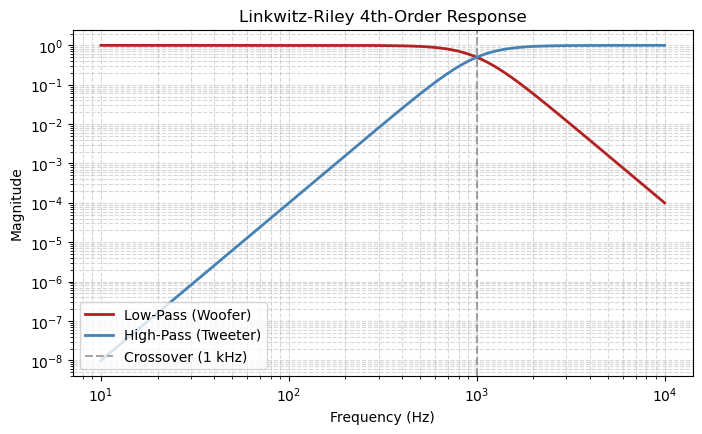

In [22]:
#| label: fig-frequency-response
#| fig-cap: "Simulated amplitude response of the High-Pass and Low-Pass filter outputs."
#| echo: false

import numpy as np
import matplotlib.pyplot as plt

# Simulate frequency array
freq = np.logspace(1, 4, 500)
# Simple ideal LR4 approximation for plotting
lp_response = 1 / (1 + (freq / 1000)**4)
hp_response = (freq / 1000)**4 / (1 + (freq / 1000)**4)

plt.figure(figsize=(8, 4.5))
plt.loglog(freq, lp_response, label='Low-Pass (Woofer)', color='firebrick', lw=2)
plt.loglog(freq, hp_response, label='High-Pass (Tweeter)', color='steelblue', lw=2)
plt.axvline(1000, color='gray', linestyle='--', alpha=0.7, label='Crossover (1 kHz)')

plt.title('Linkwitz-Riley 4th-Order Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='lower left')
plt.show()

## Component Selection

The components chosen for the analog active operational amplifier implementation are summarized below.

| Component ID | Ideal Value | Chosen Value (Standard E96) | Tolerance | Function |
|--------------|-------------|----------------------------|-----------|----------|
| $R_1, R_2$   | $15.91\text{ k}\Omega$ | $15.8\text{ k}\Omega$ | $1\%$ | Filter Node Resistors |
| $C_1, C_2$   | $10\text{ nF}$         | $10\text{ nF}$         | $5\%$ | Filter Node Capacitors |
| $U_1$        | OPA2134     | OPA2134                    | —         | Low-Noise Audio Op-Amp |

: Component selection parameters for the active filter stage. {#tbl-components}

As outlined in @tbl-components, standard resistor values are selected to match the ideal cutoff thresholds as closely as possible.

::: {.callout-note}
## Design Constraint
Ensure that the operational amplifiers used have a high enough Slew Rate (SR) and Gain-Bandwidth Product (GBW) to avoid distortion in the high-frequency band limits of the audio spectrum.
:::

# Principle of Operation: The 5-Transistor OTA (5T-OTA)

A 5-transistor operational transconductance amplifier (5T-OTA) @fig-basic-ota is a fundamental analog building block designed to convert a differential input voltage into an output current ($G = I_{\text{out}}/V_{\text{in}}$). Unlike standard operational amplifiers that ideally feature zero output resistance, an OTA is characterized by a **high output resistance**. In practical integrated circuits, these devices are often loaded capacitively to create high-gain voltage amplifiers.

![The 5-transistor OTA [@pretl2026].](./images/fig-basic-ota-output-1.svg){#fig-basic-ota width=80%}

The internal operation of an NMOS-input 5T-OTA can be broken down into three distinct operational stages:

### NMOS Differential Pair ($M_1, M_2$)
The differential pair serves as the primary "input stage" that senses the incoming voltage signals.

**Function:** $M_1$ and $M_2$ are matched NMOS devices biased by the tail current flowing from $M_5$. When a differential input voltage is applied across their gates, it is converted into **differential drain currents** governed by the transconductance ($g_{\text{m}}$) of the transistors [@pretl2026].

**Symmetry:** In an ideal, perfectly matched scenario, if the two input voltages are identical, the tail current ($I_{\text{tail}}$) splits exactly in half ($I_{\text{tail}}/2$) down both branches.
  
### NMOS Tail Current Mirror ($M_5, M_6$)
This stage establishes the stable DC **biasing** environment required for the entire amplifier circuit.

**Function:** Transistors $M_5$ and $M_6$ form a current mirror. An external reference current ($I_{\text{bias}}$) is fed through the transistor $M_6$, which is then mirrored directly into $M_5$ [@pretl2026].

**The Tail Current:** $M_5$ operates as the **tail current source**, defining the total bias current ($I_{\text{tail}}$) that passes through the input differential pair. This tail current is a critical design parameter, as it directly sets both the transconductance ($g_{\text{m}}$) and the overall speed of the amplifier.

### PMOS Current Mirror Load ($M_3, M_4$)
This final section acts as an active load for the input pair and performs the differential-to-single-ended signal conversion.

**Function:** Transistors $M_3$ and $M_4$ form a PMOS current mirror. The diode-connected $M_3$ senses the changing current flowing through the left branch ($M_1$) and replicates it over to the right branch via $M_4$ [@pretl2026].

**Summing at the Output:** At the single-ended output node, the mirrored current from $M_4$ and the direct current from the right input branch ($M_2$) are subtracted/summed. When this net signal current is forced into the high-impedance output node, it builds up the final output voltage.

## Transistor Sizing and $g_{\text{m}}/I_{\text{D}}$ Selection Strategy

In a 5T-OTA, selecting the device sizes involves balancing fundamental trade-offs between speed, power efficiency, noise, and matching. Rather than applying a uniform $g_{\text{m}}/I_{\text{D}}$ ratio across all devices, each sub-block is targeted with a specific transconductance efficiency to maximize overall circuit performance.

---

### 1. NMOS Input Differential Pair ($M_1, M_2$)

For the input stage, a **higher $g_{\text{m}}/I_{\text{D}}$ value**—typically in the range of **10 to 12 V⁻¹**—is chosen to operate the devices in moderate inversion. 

**Gain and Power Efficiency**
: The primary goal of the input pair is to provide high transconductance ($g_{\text{m}}$) to maximize the amplifier's gain. Biasing at a high $g_{\text{m}}/I_{\text{D}}$ value achieves this required transconductance while consuming the absolute minimum current ($I_{\text{D}}$), maximizing power efficiency.

**Noise and Offset Optimization**
: Maximizing the $g_{\text{m}}/I_{\text{D}}$ ratio minimizes the overdrive voltage. This is a critical strategy for reducing the input offset voltage caused by threshold voltage mismatch between $M_1$ and $M_2$, while simultaneously minimizing the input-referred thermal noise.

### 2. PMOS Load ($M_3, M_4$) and NMOS Tail ($M_5, M_6$) Current Mirrors

For the current mirror and load network, a **lower $g_{\text{m}}/I_{\text{D}}$ value**—typically in the range of **6 to 8 V⁻¹**—is chosen to operate the devices in strong inversion.

**Current Matching Accuracy**
: For current mirrors, matching accuracy takes priority over transconductance efficiency. A lower $g_{\text{m}}/I_{\text{D}}$ ratio dictates a larger overdrive voltage ($V_{\text{GS}} - V_{\text{th}}$). This larger overdrive significantly reduces current mismatch arising from local threshold voltage variations ($\Delta V_{\text{th}}$) across the mirrors.

**Output Resistance and DC Gain**
: Operating these current sources at a lower $g_{\text{m}}/I_{\text{D}}$ alongside longer channel lengths maximizes their output resistance ($r_0$). This improves both the mirroring precision and the overall DC voltage gain of the OTA.

**Noise Suppression**
: To reduce the total output noise contribution of the OTA, the transconductance of the load transistors ($g_{\text{m3,4}}$) must be kept significantly lower than the transconductance of the input pair ($g_{\text{m1,2}}$). Biasing the load devices at a lower $g_{\text{m}}/I_{\text{D}}$ ensures their individual transconductance remains small, dropping their noise contribution.

---

### 3. Summary Sizing Targets and Trade-offs

The table below outlines the final targeted $g_{\text{m}}/I_{\text{D}}$ configuration and the core trade-offs managing the 5T-OTA architecture, further narrowing the no of combinations. To streamline the simulation and optimization phase, the design space was restricted to tight $g_{\text{m}}/I_{\text{D}}$ windows. This dramatically reduces the number of design permutations and sweeps required during circuit characterization.

| Transistor Group | Inversion Region | Targeted $g_{\text{m}}/I_{\text{D}}$ Value | Key Design Priorities |
| :--- | :--- | :--- | :--- |
| **Input Pair ($M_1, M_2$)** | Moderate Inversion | 10 to 12 V⁻¹ | High gain, low power consumption, minimized offset. |
| **PMOS Load ($M_3, M_4$)** | Strong Inversion | 6 to 8 V⁻¹ | Low noise contribution, high output resistance, and precise current matching. |
| **NMOS Tail ($M_5, M_6$)** | Strong Inversion | 6 to 8 V⁻¹ | High output resistance for stable biasing and precise current replication. |

### Transistor Sizing and Architecture for the 5T-OTA

To determine the physical dimensions of the transistors within the 5T-OTA architecture, **$g_m/I_D$ design methodology** utilizes pre-characterized technology lookup tables

### Design Specification & Reference Parameters

The circuit dimensioning is driven by explicit performance targets, including bandwidth, capacitive loading, and transistor geometry constraints. The primary design inputs and initial assumptions are structured in @tbl-ota-specs.

| Parameter | Symbol | Initial Value / Target |
|:---|:---:|:---|
| **Load Capacitance** | $C_{\mathrm{load}}$ | $50\text{ fF}$ |
| **Target Bandwidth (-3dB Buffer)** | $f_{\mathrm{bw}}$ | $10\text{ MHz}$ |
| **Input Pair Efficiency Target** | $(g_m/I_D)_{1,2}$ | $10\text{ V}^{-1}$ |
| **Active Load Efficiency Target** | $(g_m/I_D)_{3,4}$ | $5\text{ V}^{-1}$ |
| **Tail Source Efficiency Target** | $(g_m/I_D)_{5,6}$ | $5\text{ V}^{-1}$ |
| **Assigned Channel Length (All)** | $L_{1-6}$ | $5\text{ }\mu\text{m}$ |
| **External Reference Bias Input** | $I_{\mathrm{bias,in}}$ | $20\text{ }\mu\text{A}$ |
| **Maximum Total Current Limit** | $I_{\mathrm{total,limit}}$ | $10\text{ }\mu\text{A}$ |

: Input design parameters and specifications for the 5T-OTA as per sizing document in [@pretl2026]. {#tbl-ota-specs}

---

### Sizing Derivations & Mathematical Formulations

#### Input Pair Transconductance ($g_m$) Extraction
The required transconductance for the differential input pair ($M_{1/2}$) is directly tied to the unity-gain bandwidth requirement of the system configuration. To protect against process, voltage, and temperature (PVT) variations, alongside parasitic transistor self-loading, a safety scaling factor of $3$ is introduced into the fundamental bandwidth equation:

$$g_{m1,2} = f_{\mathrm{bw}} \cdot 3 \cdot 4\pi \cdot C_{\mathrm{load}}$$

Substituting our core specifications ($10\text{ MHz}$ and $50\text{ fF}$), the script calculates the necessary small-signal capability:

$$g_{m1,2} = 10\text{ MHz} \cdot 3 \cdot 4\pi \cdot 50\text{ fF} \approx 0.0188\text{ mS}$$

#### Bias Current Evaluation
By establishing the transconductance efficiency parameter $(g_m/I_D)_{1,2} = 10$, the single-branch bias current ($I_{D1,2}$) can be isolated:

$$I_{D1,2} = \frac{g_{m1,2}}{(g_m/I_D)_{1,2}}$$

The total tail current required from current source $M_5$ corresponds to both operational branches:

$$I_{\mathrm{total}} = 2 \cdot I_{D1,2} \approx 3.76\text{ }\mu\text{A}$$

To comply with standard layout grids and bias generation modules, this value is rounded up to a clean operational baseline of **$4.0\text{ }\mu\text{A}$** ($I_{D1,2} = 2.0\text{ }\mu\text{A}$).

#### Gate Voltage & Physical Width Mapping
Operating at a fixed bias length ($L = 5\text{ }\mu\text{m}$), the calculated current and target efficiency points are mapped to the semiconductor technology databases to track their native gate-to-source voltage drops ($V_{\mathrm{GS}}$):

Using the technology-specific current density value per micrometer of transistor width ($I_D/W$) provided by the lookup tables at these operating points, the physical widths ($W$) are computed via:

$$W = \frac{I_D}{(I_D/W)}$$

and rounded

#### External Bias Current Mirroring ($M_6$)
To mirror the incoming off-chip reference current ($20\text{ }\mu\text{A}$) down to our internal tail target ($4\text{ }\mu\text{A}$), the geometry of the receiving diode-connected transistor ($M_6$) is scaled proportionally against the dimensions of $M_5$:

$$W_6 = W_{5,\mathrm{round}} \cdot \frac{I_{\mathrm{bias,in}}}{I_{\mathrm{total}}}$$

#### Open-Loop DC Gain Derivation

The open-loop DC voltage gain ($A_0$) of a single-stage 5T-OTA is defined by the transconductance of the input pair relative to the combined output conductances ($g_{\mathrm{ds}}$) of both the input transistors and the active loads. 

The total small-signal DC voltage gain is expressed using the following equation:

$$A_0 = \frac{g_{m1,2}}{g_{\mathrm{ds}1,2} + g_{\mathrm{ds}3,4}}$$

We can use the readly available sizing document to size a basic 5T-OTA, based on the input design parameters the document caculates the sizing for each transistor and other parameters like the gain, noise, power consumption and settling time. A sizing document is available at [@pretl2026]

## Transition to a Two-Stage OTA Architecture

### Why the 5T-OTA is Insufficient for Audio
While the basic 5T-OTA is simple and efficient, it is not suitable for an audio amplifier because its open-loop DC gain is only **$34.8\text{ dB}$** (around $55\text{ V/V}$). High-fidelity audio applications demand significantly more gain to ensure precise signal reproduction, minimize output distortion, and keep gain errors low. 

Because a single transistor stage cannot provide enough amplification on its own, we must transition to a **Two-Stage OTA** architecture as suggested in [@pretl2026].

### The Two-Stage Gain Equation
By cascading a second amplification stage directly after the initial differential stage, the total open-loop gain is multiplied together. The resulting total DC voltage gain is defined by the following equation:

$$A_{\mathrm{OL, total}} = A_{v1} \cdot A_{v2}$$

Where: $A_{\mathrm{OL, total}}$ is the total open-loop DC gain of the system. $A_{v1}$ is the voltage gain of the first stage (the differential input pair). $A_{v2}$ is the voltage gain of the second stage (the common-source output stage).

This structural change easily pushes the total gain into the desired range for audio quality, while the added Miller compensation network ($C_\mathrm{M}$ and $R_\mathrm{Z}$) ensures the entire circuit remains stable.

## Transistor Sizing and Architecture for the 2-Stage Miller OTA

Integral part of an Linkwitz-Riley 4 Crossover Filter is an amplifier, and a 2-stage OTA is a good option as it offers high gain and is begginer friendly to design. A 2-stage OTA is essentially an 5-T OTA and a PMOS common source ampliflier cascaded with a Miller compensation capacitor $C_{\text{M}}$ and a Null resistor $R_{\text{Z}}$ as shown in @fig-2-stage-ota.

![The 2-stage OTA.](./images/fig-ota-se-twostage-output-1.svg){#fig-2-stage-ota width=80%}

There are 4 major aspects of this OTA the input differential pair, pmos current mirrors, output gain PMOS, and tail current NMOS's. The sizing of these transistors is done using gm/Id methodology. 

### 1. Design Specification & Reference Parameters

The core target constraints, technology limits, and initial efficiency definitions guiding the automation loop are outlined in @tbl-2stage-specs[cite: 3].

| Parameter | Symbol | Initial Value / Target |
|:---|:---:|:---|
| **Load Capacitance** | $C_{\mathrm{load}}$ | $1\text{ pF}$[cite: 3] |
| **Target Bandwidth (-3dB Buffer)** | $f_{\mathrm{bw}}$ | $10\text{ MHz}$[cite: 3] |
| **Input Pair Efficiency Target** | $(g_m/I_D)_{1,2}$ | $11\text{ V}^{-1}$[cite: 3] |
| **Active Load Efficiency Target** | $(g_m/I_D)_{3,4}$ | $7\text{ V}^{-1}$[cite: 3] |
| **CS Driver Efficiency Target** | $(g_m/I_D)_{5}$ | $10\text{ V}^{-1}$[cite: 3] |
| **Current Mirror Efficiency Target** | $(g_m/I_D)_{6,7,8}$ | $6\text{ V}^{-1}$[cite: 3] |
| **Assigned Channel Length (All)** | $L_{1-8}$ | $2\text{ }\mu\text{m}$[cite: 3] |
| **Target Open-Loop DC Gain** | $A_0$ | $\ge 60\text{ dB}$[cite: 3] |
| **Core Current Draw Budget** | $I_{\mathrm{limit}}$ | $\le 30\text{ }\mu\text{A}$[cite: 3] |

: Design specifications and biasing conditions for the 2-Stage Miller OTA optimization. {#tbl-2stage-specs}

---

### 2. Sizing Derivations & Mathematical Formulations

#### Step A: Compensation Allocation & First-Stage Sizing
To shield the circuit from high-frequency stability decay, a Miller capacitance ($C_\mathrm{M}$) is introduced relative to the total output load[cite: 3]:

$$C_\mathrm{M} = 0.5 \cdot C_{\mathrm{load}} = 500\text{ fF}$$[cite: 3]

The input pair transconductance ($g_{m1,2}$) calculation incorporates a protective $3\times$ multiplier scaling to safeguard the target bandwidth against local process tracking shifts[cite: 3]:

$$g_{m1,2,\mathrm{ideal}} = 3 \cdot (2\pi f_{\mathrm{bw}}) \cdot C_\mathrm{M} \approx 0.09425\text{ mS}$$[cite: 3]

Dividing by the efficiency parameter $(g_m/I_D)_{1,2} = 11$, the branch current yields a total ideal tail allocation of $I_{\mathrm{tail,ideal}} \approx 17.14\text{ }\mu\text{A}$[cite: 3]. Quantizing this to a regular layout grid (steps of $0.5\text{ }\mu\text{A}$) locks in our tail profile[cite: 3]:

* **Tail Current Source ($I_{\mathrm{tail}}$):** **$17.00\text{ }\mu\text{A}$**[cite: 3]
* **True Branch Current ($I_{D1,2}$):** **$8.50\text{ }\mu\text{A}$**[cite: 3]
* **True Manufactured Transconductance ($g_{m1,2}$):** $11 \cdot 8.5\text{ }\mu\text{A} = \mathbf{0.09350\text{ mS}}$[cite: 3]

#### Step B: Second-Stage Stability & Resistor Calibration
To guarantee a robust phase margin, the secondary transconductance stage ($M_5$) must easily out-pace the target operational bandwidth boundary via an image-sizing coefficient rule[cite: 3]:

$$g_{m5,\mathrm{req}} = 2.2 \cdot f_{\mathrm{bw}} \cdot 2\pi \cdot C_{\mathrm{load}} \approx 0.13823\text{ mS}$$[cite: 3]

Dividing this by its distinct parameter $(g_m/I_D)_5 = 10$ establishes the analytical current demand $I_{D5,\mathrm{req}} = 13.823\text{ }\mu\text{A}$[cite: 3]. Mirror scaling constraints align the true current flow down to exactly **$10.00\text{ }\mu\text{A}$** based on physical layout sizes[cite: 3]. At this grid point, the driver generates its final small-signal capability:

$$g_{m5} = (g_m/I_D)_5 \cdot I_{D5} = 10 \cdot 10\text{ }\mu\text{A} = \mathbf{0.10000\text{ mS}}$$[cite: 3]

The zero-nulling frequency compensation resistance ($R_z$) is set to cancel the right-half-plane (RHP) zero generated across the Miller framework[cite: 3]:

$$R_z = \frac{2}{g_{m5}} = \mathbf{20.00\text{ k}\Omega}$$[cite: 3]

---

### 3. Sizing Optimization Results

The physical layout dimensions established by mapping the grid current data back to the `pygmid` database lookup functions are structured in @tbl-2stage-results[cite: 3].

| Transistor Group | Geometric Layout Role | Width ($W$) | Length ($L$) |
|:---|:---|:---:|:---:|
| **$M_{1/2}$** | NMOS Input Differential Pair | $2.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_{3/4}$** | PMOS Active First-Stage Load | $3.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_5$** | PMOS Common-Source Output Driver | $9.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_6$** | NMOS External Reference Bias Input Receiver | $2.0\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_7$** | NMOS First-Stage Tail Current Mirror | $1.5\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |
| **$M_8$** | NMOS Second-Stage Output Active Load | $1.0\text{ }\mu\text{m}$ | $2\text{ }\mu\text{m}$ |

: Final optimized structural dimensions for the 2-Stage Miller OTA. {#tbl-2stage-results}

---

### 4. Open-Loop DC Gain & Performance Evaluation

By splitting the design across cascaded active blocks, the total system gain successfully clears the targets required for robust distortion control. The cumulative performance metrics are detailed in @tbl-2stage-perf[cite: 3].

| Performance Metric | Design Value | Status / Constraint |
|:---|:---:|:---|
| **Stage 1 Gain ($A_1$)** | **$31.6\text{ dB}$**[cite: 3] | Primary Voltage Boost[cite: 3] |
| **Stage 2 Gain ($A_2$)** | **$34.3\text{ dB}$**[cite: 3] | Secondary Common-Source Boost[cite: 3] |
| **Total Open-Loop Gain ($A_0$)** | **$65.9\text{ dB}$**[cite: 3] | **Passed** ($\ge 60\text{ dB}$ Target)[cite: 3] |
| **Voltage Gain Error ($\epsilon$)** | **$-0.1\%$**[cite: 3] | Minimizes Closed-Loop Tracking Shifts[cite: 3] |
| **Core Branch Current Draw** | **$27.00\text{ }\mu\text{A}$**[cite: 3] | **Passed** ($\le 30.00\text{ }\mu\text{A}$ Budget)[cite: 3] |
| **Peak Power Dissipation** | **$72.85\text{ }\mu\text{W}$**[cite: 3] | Simulated at $V_{\mathrm{DD,max}} = 1.55\text{ V}$[cite: 3] |
| **Effective Miller Load ($C_{\mathrm{M,eff}}$)**| **$599.54\text{ fF}$**[cite: 3] | Includes $99.54\text{ fF}$ internal parasitics[cite: 3] |
| **Predicted Layout UGBW** | **$24.82\text{ MHz}$**[cite: 3] | Exceeds $10\text{ MHz}$ baseline specification[cite: 3] |

: Performance summary of the 2-Stage Miller OTA configuration. {#tbl-2stage-perf}

## Frequency Response and Stability Analysis: 5T vs. 2-Stage Miller OTA

### 1. 5T OTA Performance with $L = 5\ \mu\text{m}$
The initial design of a single-stage 5T Operational Transconductance Amplifier (OTA) targeted an audio-frequency **Unity-Gain Bandwidth (UGBW) of 10 MHz**. Using a large channel length of $L = 5\ \mu\text{m}$ was successful in this architecture. Because a 5T OTA is a single-stage topology, its frequency response is dictated by a single dominant pole at the output. Any secondary, non-dominant poles lie far enough beyond the 10 MHz target that they do not impact loop stability.



### 2. 2-Stage Miller OTA: The $L = 5\ \mu\text{m}$ Instability
When expanding the design to a **2-Stage Miller-Compensated OTA** using the same $L = 5\ \mu\text{m}$ for the gain stages, the frequency response exhibited prominent **peaking ("bumps") at high frequencies**, indicating a severe degradation of Phase Margin and potential circuit instability.

To diagnose this, the $f_{\text{T}}$ vs. $g_{\text{m}}/I_{\text{D}}$ characteristic plot for the `sg13_lv_nmos` device was analyzed:
* For $L = 5\ \mu\text{m}$, the transit frequency ($f_{\text{T}}$) curve is nearly completely flat across the moderate inversion region ($g_{\text{m}}/I_{\text{D}} = 10 \text{ to } 15\text{ S/A}$), hovering at a very low absolute value.
* This flatness demonstrates that at $L = 5\ \mu\text{m}$, the transistor's local speed capability is heavily restricted regardless of the biasing condition.
* In a 2-stage amplifier, the second gain stage creates a critical non-dominant pole. Because the $L = 5\ \mu\text{m}$ device is fundamentally limited in speed, this non-dominant pole was trapped too close to the target 10 MHz UGBW, leading to the observed high-frequency peaking.



### 3. Optimization and Resolution via $L = 2\ \mu\text{m}$
Based on the insights from the $f_{\text{T}}$ plot, the channel length was reduced to **$L = 2\ \mu\text{m}$** to shift the device operating point onto a higher, more dynamic speed curve. 

* **Result:** Decreasing $L$ successfully pushed the non-dominant pole to a significantly higher frequency, well out of the way of the audio bandwidth. 
* Combined with a minor increase in the Miller compensation capacitance ($C_{\text{M}}$) to cleanly split the poles, the high-frequency bumps were completely eliminated. This yielded a smooth, stable open-loop roll-off with a robust phase margin and a well-defined UGBW of 10 MHz.

# References